In [2]:
import desc
import numpy as np
import sys

sys.path.insert(0, r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt")
sys.path.insert(0, r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_contrib")

from xicsrt_contrib.sources._XicsrtPlasmaVmec import XicsrtPlasmaVmec

woutfile = r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\wout.nc"

# Create plasma source with no positional argument
source = XicsrtPlasmaVmec(initialize=False)

# Store the wout file in the config/parameters
source.param["wout_file"] = woutfile

# Load VMEC/DESC equilibrium
source.initialize_vmec()

C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\DESC\desc\vmec.py:93: UserWarning: VMEC output appears to be from version 8.48 while DESC is only designed for compatibility with VMEC version 9. Some data may not be loaded correctly.
  warnings.warn(


In [3]:
# 2. Create Original Point in Flux Coordinates
point_flx = np.array([[0.2, 0.0, 0.2]]) # 2D array because [[]]
print("\nOriginal Flux Point:")
print(point_flx)

# 3. Convert to Cartesian Coordinates
point_car = source.car_from_flx(point_flx)
print("\nConverted to Cartesian Coordinates")
print(point_car)

# 4. Convert to Cylindrical Coordinates
point_cyl = source.cyl_from_car(point_car)
print("\nConverted to Cylindrical Coordinates")
print(point_cyl)

# 5. Converted Back to Original Flux Coordinates
new_point_flx = source.flx_from_cyl(point_cyl)
print("\nConverted Back to Original Flux Coordinates")
print(point_flx)


Original Flux Point:
[[0.2 0.  0.2]]

Converted to Cartesian Coordinates
[[5.71738221 1.15897075 0.23957353]]

Converted to Cylindrical Coordinates
[[5.83366716 0.2        0.23957353]]

Converted Back to Original Flux Coordinates
[[0.2 0.  0.2]]


In [4]:
# 6. Finding temperature, emissivity, and velocity for every ray bundle 
bundle_input = {
    "origin": np.array(point_car),
    "temperature": np.zeros(1),
    "emissivity": np.zeros(1),
    "velocity": np.zeros((1, 3)),
    "mask": np.array([True]),
}

bundle_input = source.bundle_generate(bundle_input)

print("temperature:")
print(bundle_input["temperature"])

print("emissivity:")
print(bundle_input["emissivity"])

print("velocity:")
print(bundle_input["velocity"])


C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\DESC\desc\vmec.py:93: UserWarning: VMEC output appears to be from version 8.48 while DESC is only designed for compatibility with VMEC version 9. Some data may not be loaded correctly.
  warnings.warn(


temperature:
[0.]
emissivity:
[0.]
velocity:
[[0. 0. 0.]]


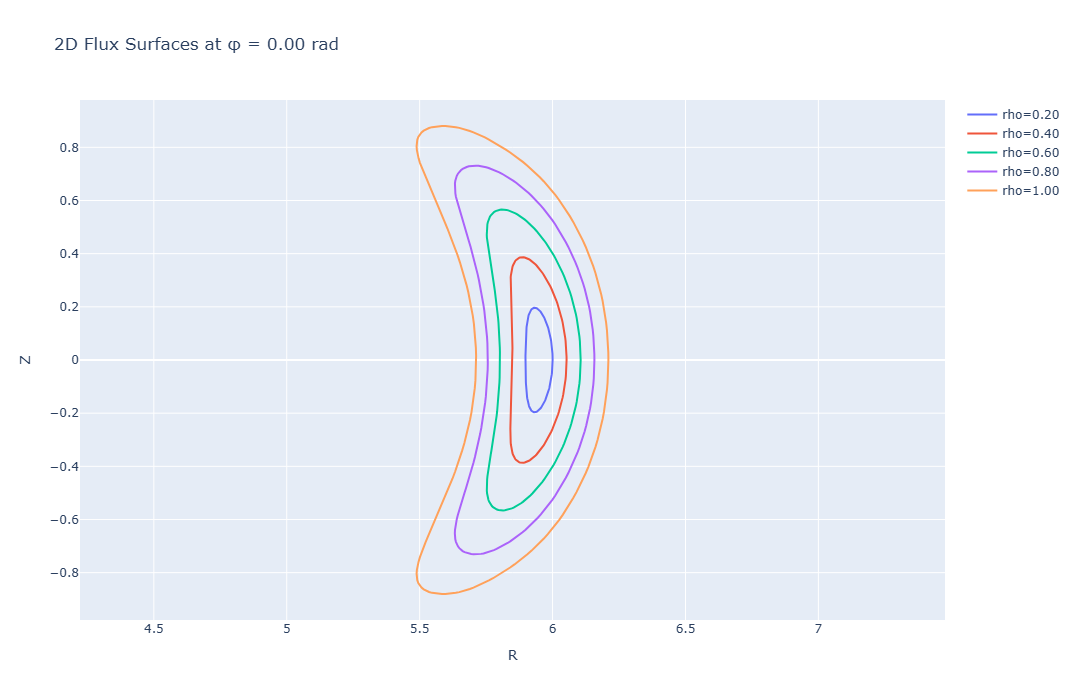

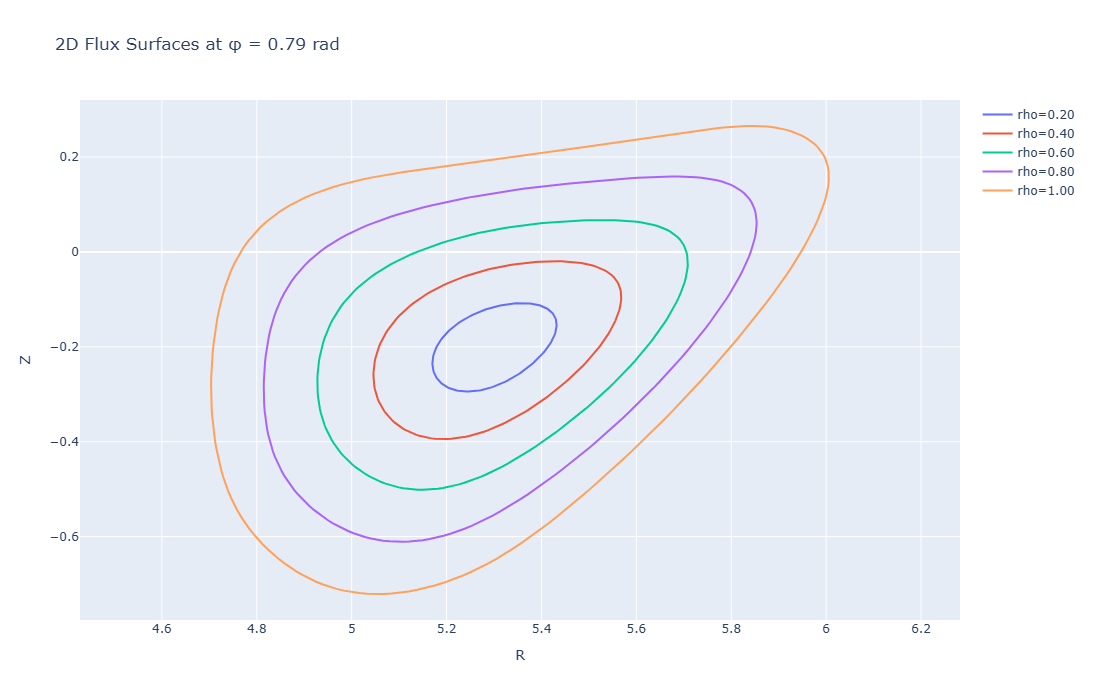

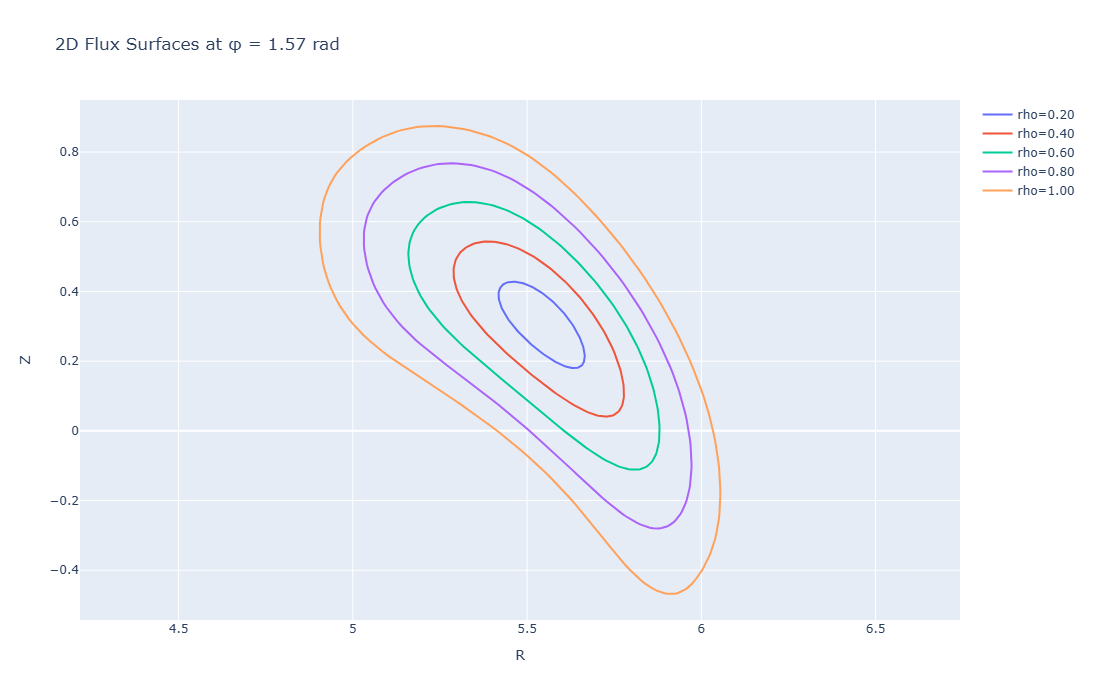

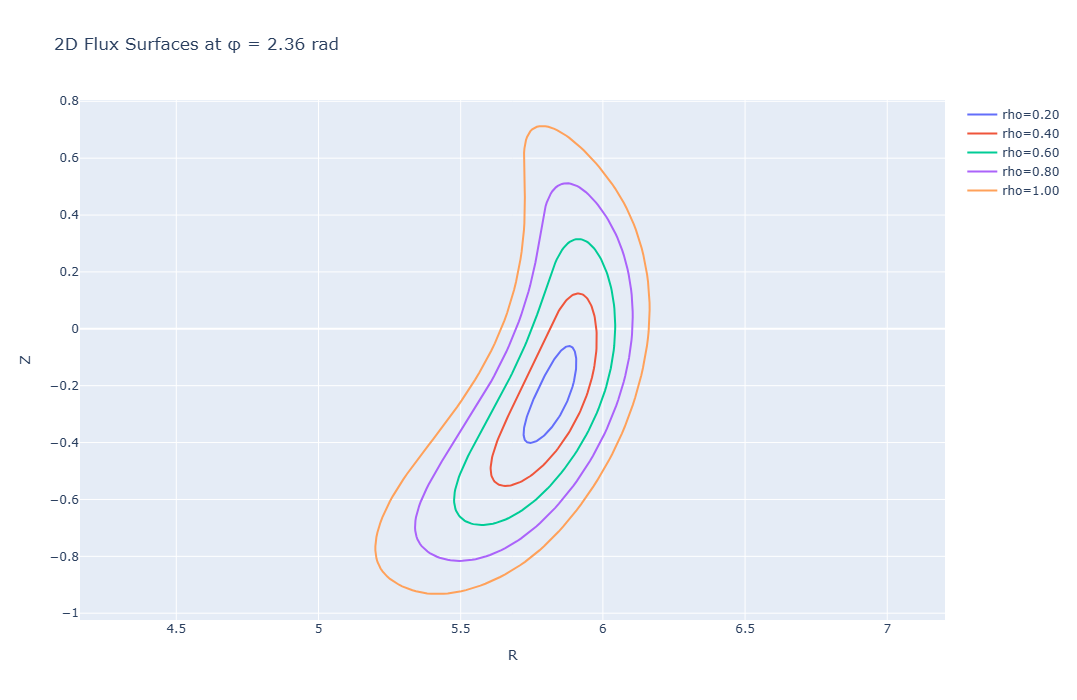

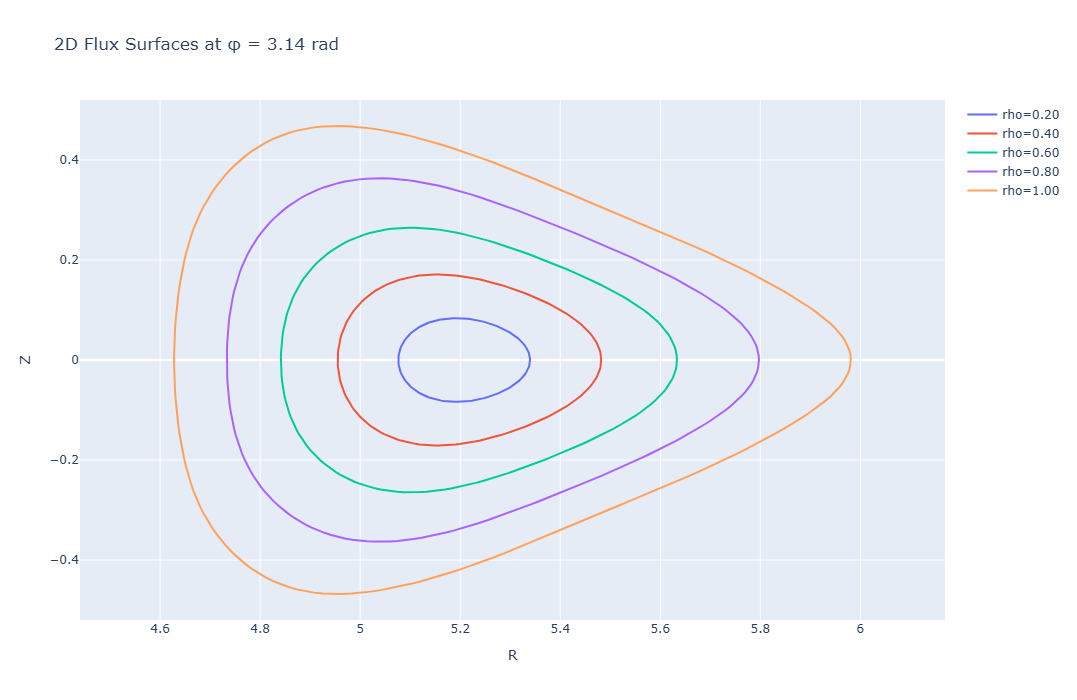

In [5]:
# 7. Generating 2D plots of the plasma equilibrium at different phi values
# using the 'plotly' Python library

import numpy as np
import plotly.graph_objects as go

# phi values to plot
phi_values = [0.0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]

# flux surfaces and poloidal angle samples
rho = source.rho_from_car(point_car)
rho_values = np.linspace(0.2, 1.0, 5)
theta_values = np.linspace(0.0, 2*np.pi, 200)

for phi in phi_values:

    fig = go.Figure() 
    
    for rho in rho_values:
        
        # create 2D flux-coordinate array with shape (N,3)
        point_flx = np.column_stack([
            np.full_like(theta_values, rho),     # rho column (radial coordinate)
            theta_values,                        # theta column (poloidal angle)
            np.full_like(theta_values, phi)      # phi column (toroidal angle)
        ])

        # convert flux coordinates to cylindrical coordinates
        point_cyl = source.cyl_from_flx(point_flx)
        R = point_cyl[:, 0]
        Z = point_cyl[:, 2]

        fig.add_trace(
            go.Scatter(
                x = R,
                y = Z, 
                mode = "lines", 
                name = f"rho={rho:.2f}"
            )
        )

    fig.update_layout(
        title = f"2D Flux Surfaces at φ = {phi:.2f} rad",
        xaxis_title = "R",
        yaxis_title = "Z",            
        width = 900,
        height = 700,
        
    )

    fig.update_yaxes(scaleanchor="x", scaleratio=1)
    fig.show()



In [6]:
# 8. Testing to see what DESC returns when there is a point outside LCFS
# Result: DESC returns a value of 1 when a point is outside of the domain

points = np.array([
    [6.0, 0.0, 0.0],   # likely inside the LCFS
    [100.0, 0.0, 0.0], # likely outside the LCFS
])

rho = source.rho_from_car(points)

print(rho)

[0.19912863 1.        ]
